In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load features and target from parquet files
features_path = "../data/user_activity/featured/features_balanced.parquet"
target_path = "../data/user_activity/featured/target_balanced.parquet"

X = pd.read_parquet(features_path)
y_loaded = pd.read_parquet(target_path)

print(X.columns)

Index(['posts_total', 'posts_avg', 'posts_active_days', 'posts_day0',
       'blocks_initiated_total', 'blocks_received_total',
       'blocks_initiated_active_days', 'blocks_received_active_days',
       'follows_made_total', 'follows_received_total',
       'follows_made_active_days', 'follows_received_active_days',
       'likes_made_total', 'likes_received_total', 'likes_made_active_days',
       'likes_received_active_days', 'blocks_ratio_initiated_received',
       'blocks_initiated_per_active_day', 'blocks_net_balance',
       'blocks_to_posts_ratio', 'blocks_to_follows_ratio',
       'posts_first_active_day', 'posts_last_active_day',
       'follows_made_first_day', 'follows_made_last_day',
       'likes_made_first_day', 'likes_made_last_day',
       'blocks_initiated_first_day', 'blocks_initiated_last_day',
       'last_active_overall'],
      dtype='object')


## Single-Output Week 2 Prediction Strategy

We'll train **single-output models** that predict block activity class for week 2 from week 1 features:
- 0 blocks -> class 0 (Inactive)
- 1–3 blocks -> class 1 (Low activity)
- 4+ blocks -> class 2 (High activity)

**Key approach:**
- Single model takes week 1 features as input
- Outputs 1 prediction: week2_class
- Uses standard sklearn classifiers

**Goals:**
1. Predict user behavior for the next week (week 2)
2. Compare different models: Logistic Regression, Random Forest, Gradient Boosting
3. Visualize confusion matrices and performance metrics

This helps us understand immediate next-week behavioral patterns.

In [3]:
# Extract class target for week 2 only
print("Available target columns:")
print(y_loaded.columns.tolist())

# Use the pre-computed class column from feature engineering
y = y_loaded['blocks_week2_class'].astype(int)

print('\nTarget shape:', y.shape)
print('Sample targets (first 10 users):')
print(y.head(10))

# Display class distribution
print('\n' + '='*70)
print('WEEK 2 CLASS DISTRIBUTION')
print('='*70)

print('\nWeek 2 class distribution:')
dist = y.value_counts().sort_index()
print(dist)
print(f'Percentages: {(y.value_counts(normalize=True).sort_index() * 100).round(2).to_dict()}')

# Sample check
print('\n' + '='*70)
print('Sample target values (first 10 users):')
sample_df = pd.DataFrame({
    'did_id': y_loaded['did_id'].head(10).values,
    'week2_class': y.head(10).values
})
print(sample_df.to_string(index=False))

Available target columns:
['did_id', 'blocks_week2_initiated', 'blocks_week2_class', 'blocks_week3_initiated', 'blocks_week3_class', 'blocks_week4_initiated', 'blocks_week4_class']

Target shape: (76074,)
Sample targets (first 10 users):
0    1
1    0
2    0
3    0
4    1
5    0
6    0
7    1
8    1
9    2
Name: blocks_week2_class, dtype: int64

WEEK 2 CLASS DISTRIBUTION

Week 2 class distribution:
blocks_week2_class
0    25358
1    25358
2    25358
Name: count, dtype: int64
Percentages: {0: 33.33, 1: 33.33, 2: 33.33}

Sample target values (first 10 users):
  did_id  week2_class
33129713            1
 9862367            0
14322389            0
 1394492            0
19181694            1
 6209735            0
 7129639            0
31525415            1
32942746            1
31101508            2


In [10]:
# Prepare data for single-output models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=42, stratify=y
)

print(f'Train/Test split: {X_train.shape} / {X_test.shape}')
print(f'Target: {y_train.shape} / {y_test.shape}')

# Scale features (will be used for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check class distribution in train set
print('\nTrain set class distribution:')
print(y_train.value_counts(normalize=True).sort_index().to_dict())

print('\n✓ Data prepared for models')

Train/Test split: (15214, 30) / (60860, 30)
Target: (15214,) / (60860,)

Train set class distribution:
{0: 0.33337715262258444, 1: 0.33331142368870775, 2: 0.33331142368870775}

✓ Data prepared for models


### Train Models for Week 2 Prediction

We'll train three types of models to predict week 2 activity class.

In [12]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

print('='*80)
print('TRAINING LOGISTIC REGRESSION')
print('='*80)

# Create classifier
lr_model = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs',
    max_iter=1000, 
    class_weight='balanced',
    random_state=42
)

# Train on scaled data
print('\nTraining model (predicts week 2)...')
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Compute metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')
f1_weighted_lr = f1_score(y_test, y_pred_lr, average='weighted')
cm_lr = confusion_matrix(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)

print(f'\nWeek 2 Results:')
print(f'  Accuracy: {acc_lr:.4f}')
print(f'  Macro F1: {f1_macro_lr:.4f}')
print(f'  Weighted F1: {f1_weighted_lr:.4f}')

print('\n✓ Logistic Regression trained')

TRAINING LOGISTIC REGRESSION

Training model (predicts week 2)...

Week 2 Results:
  Accuracy: 0.3360
  Macro F1: 0.3339
  Weighted F1: 0.3339

✓ Logistic Regression trained


### Train Random Forest

In [13]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

print('='*80)
print('TRAINING RANDOM FOREST')
print('='*80)

# Create classifier with optimized parameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train on raw data (tree models don't need scaling)
print('\nTraining model (predicts week 2)...')
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Compute metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)

print(f'\nWeek 2 Results:')
print(f'  Accuracy: {acc_rf:.4f}')
print(f'  Macro F1: {f1_macro_rf:.4f}')
print(f'  Weighted F1: {f1_weighted_rf:.4f}')

print('\n✓ Random Forest trained')

TRAINING RANDOM FOREST

Training model (predicts week 2)...

Week 2 Results:
  Accuracy: 0.3302
  Macro F1: 0.3300
  Weighted F1: 0.3300

✓ Random Forest trained

Week 2 Results:
  Accuracy: 0.3302
  Macro F1: 0.3300
  Weighted F1: 0.3300

✓ Random Forest trained


### Train Gradient Boosting

In [7]:
# Train Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

print('='*80)
print('TRAINING GRADIENT BOOSTING')
print('='*80)

# Create classifier
gb_model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100
)

# Train on raw data
print('\nTraining model (predicts week 2)...')
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Compute metrics
acc_gb = accuracy_score(y_test, y_pred_gb)
f1_macro_gb = f1_score(y_test, y_pred_gb, average='macro')
f1_weighted_gb = f1_score(y_test, y_pred_gb, average='weighted')
cm_gb = confusion_matrix(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb, output_dict=True, zero_division=0)

print(f'\nWeek 2 Results:')
print(f'  Accuracy: {acc_gb:.4f}')
print(f'  Macro F1: {f1_macro_gb:.4f}')
print(f'  Weighted F1: {f1_weighted_gb:.4f}')

print('\n✓ Gradient Boosting trained')

# Consolidate all results
all_results = {
    'LogisticRegression': {
        'accuracy': acc_lr,
        'f1_macro': f1_macro_lr,
        'f1_weighted': f1_weighted_lr,
        'confusion_matrix': cm_lr,
        'classification_report': report_lr,
        'y_pred': y_pred_lr
    },
    'RandomForest': {
        'accuracy': acc_rf,
        'f1_macro': f1_macro_rf,
        'f1_weighted': f1_weighted_rf,
        'confusion_matrix': cm_rf,
        'classification_report': report_rf,
        'y_pred': y_pred_rf
    },
    'GradientBoosting': {
        'accuracy': acc_gb,
        'f1_macro': f1_macro_gb,
        'f1_weighted': f1_weighted_gb,
        'confusion_matrix': cm_gb,
        'classification_report': report_gb,
        'y_pred': y_pred_gb
    }
}

print('\n' + '='*80)
print('ALL MODEL TRAINING COMPLETE')
print('='*80)

TRAINING GRADIENT BOOSTING

Training model (predicts week 2)...

Week 2 Results:
  Accuracy: 0.3328
  Macro F1: 0.3327
  Weighted F1: 0.3327

✓ Gradient Boosting trained

ALL MODEL TRAINING COMPLETE

Week 2 Results:
  Accuracy: 0.3328
  Macro F1: 0.3327
  Weighted F1: 0.3327

✓ Gradient Boosting trained

ALL MODEL TRAINING COMPLETE


MODEL PERFORMANCE COMPARISON (WEEK 2)
             Model  Accuracy  Macro F1  Weighted F1
LogisticRegression  0.334175  0.332509     0.332509
      RandomForest  0.334674  0.334652     0.334652
  GradientBoosting  0.332834  0.332662     0.332662


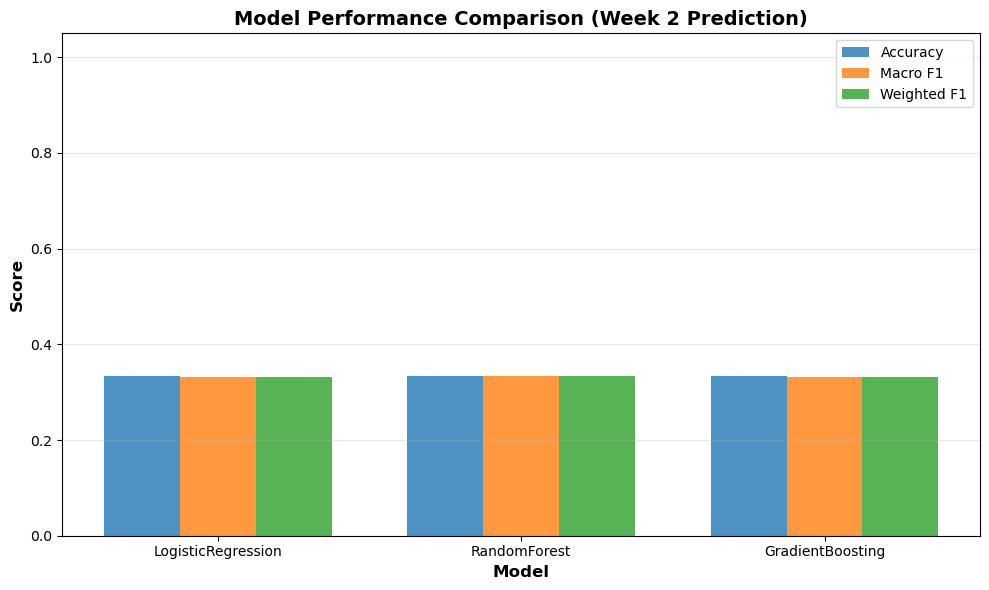


BEST MODEL (by Macro F1)
RandomForest (Macro F1 = 0.3347)


In [8]:
# Comparative performance visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create performance comparison table
performance_data = []
for model_name in ['LogisticRegression', 'RandomForest', 'GradientBoosting']:
    res = all_results[model_name]
    performance_data.append({
        'Model': model_name,
        'Accuracy': res['accuracy'],
        'Macro F1': res['f1_macro'],
        'Weighted F1': res['f1_weighted']
    })

perf_df = pd.DataFrame(performance_data)

print('='*80)
print('MODEL PERFORMANCE COMPARISON (WEEK 2)')
print('='*80)
print(perf_df.to_string(index=False))

# 2. Visual comparison: bar plots of metrics
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
x = np.arange(len(performance_data))
width = 0.25

colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, metric in enumerate(metrics):
    values = [perf_df.iloc[i][metric] for i in range(len(perf_df))]
    ax.bar(x + idx * width, values, width, label=metric, alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (Week 2 Prediction)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(perf_df['Model'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# 3. Best model
print('\n' + '='*80)
print('BEST MODEL (by Macro F1)')
print('='*80)
best_model = max(all_results.items(), key=lambda x: x[1]['f1_macro'])
print(f"{best_model[0]} (Macro F1 = {best_model[1]['f1_macro']:.4f})")

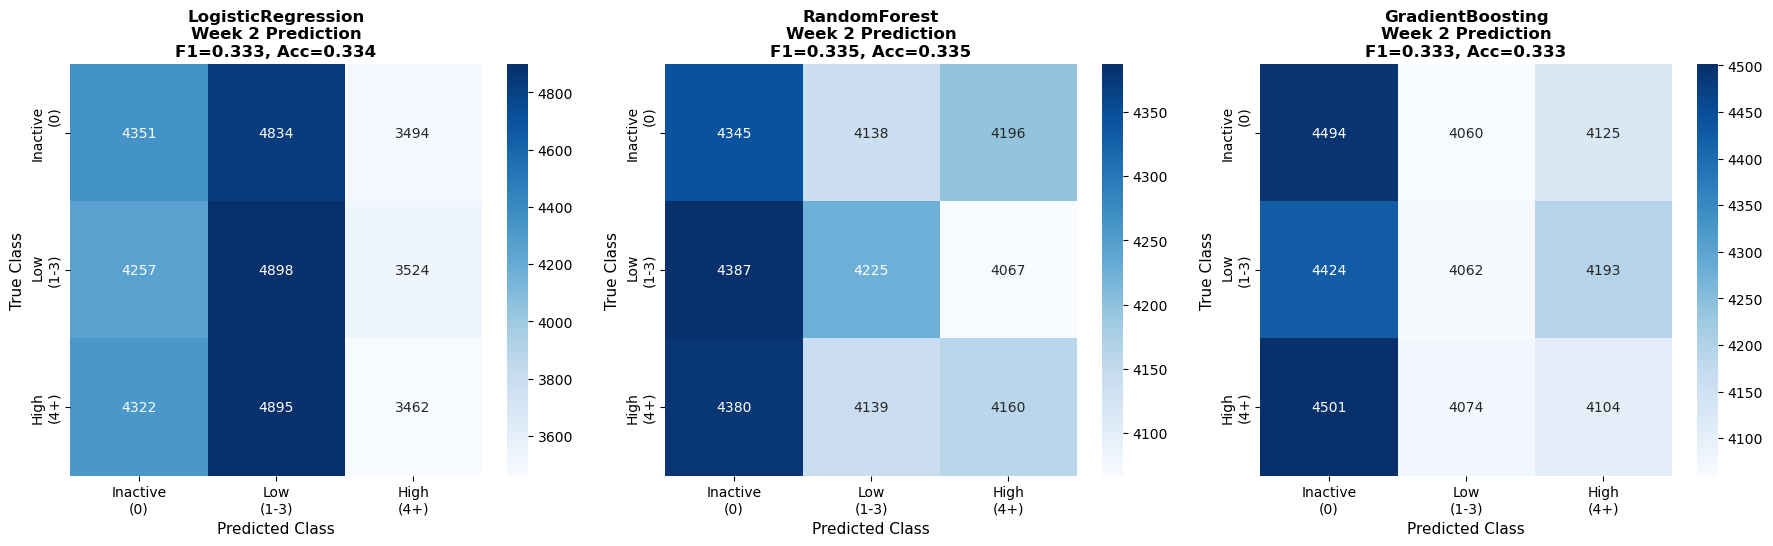

In [9]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Inactive\n(0)', 'Low\n(1-3)', 'High\n(4+)']

for idx, (model_name, model_results) in enumerate(all_results.items()):
    ax = axes[idx]
    cm = model_results['confusion_matrix']
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                cbar=True, square=True)
    
    f1 = model_results['f1_macro']
    acc = model_results['accuracy']
    ax.set_title(f'{model_name}\nWeek 2 Prediction\nF1={f1:.3f}, Acc={acc:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('True Class', fontsize=11)

plt.tight_layout()
plt.show()